In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import glob

# __In this analysis, the objective should be to check out the differents datasets we can gathered, evaluated the utility and normalize the format.__

### __First we are starting with scaomath_NS (Navier stokes) according to their description in HugginFace. The dataset contains tensor-type objects which contains data of isothropic turbulence (James C. McWilliams-1984)and inverse cascade turbulence (Andrey Kolmogorov-1941). The data was generated by a pseudo-spectral solver with 4th-order Runge-Kutta for the convection term, or a higher order Finite Volume IMEX methods__


#### __Kolmogorov2d_fp32_64x64_N1152_Re1000_T100.pt__

The principal characteristic of the Kolmogorov flow is that the fluid motion is driven by an external sinusoidal forcing. The forcing is typically applied in one spatial direction and has the form

$$
f(y) = F_0 \sin(k y)
$$

where $k$ is the wavenumber and $F_0$ is the forcing amplitude. This forcing generates a spatially periodic shear pattern in the flow and is commonly used to study hydrodynamic instabilities, transition to turbulence, and energy cascades in a controlled setting.

In [2]:
path = '/media/joseluis/HDD/Proyecto CFD/datasets/scaomath_NS/Kolmogorov2d_fp32_64x64_N1152_Re1000_T100.pt'
data = torch.load(path, map_location='cpu', weights_only=False)

In [3]:
print(type(data))
print(data.keys())

<class 'collections.defaultdict'>
dict_keys(['vorticity', 'stream', 'vort_t', 'residual', 'random_states'])


In [4]:
for key in data.keys():
    val = data[key]
    print("Feature: ",key)
    print("Type of value in it: ",val.dtype)
    print("------------------------------------|")

Feature:  vorticity
Type of value in it:  torch.float32
------------------------------------|
Feature:  stream
Type of value in it:  torch.float32
------------------------------------|
Feature:  vort_t
Type of value in it:  torch.float32
------------------------------------|
Feature:  residual
Type of value in it:  torch.float32
------------------------------------|
Feature:  random_states
Type of value in it:  torch.int32
------------------------------------|


In [5]:
print(data['vorticity'].shape)

torch.Size([1152, 100, 64, 64])


The definitions of the categories are:

* Vorticity: $ \omega = \partial v/\partial x - \partial u/\partial y $.  It is a scalar field representing the local rotation of the fluid and is the main field used for training.
* stream: $ \psi $, related to the velocity components by  $ u = \partial \psi/\partial y $ and $ v = -\partial \psi/\partial x $.
* vort_t:  $ \partial \omega / \partial t $. It represents the rate of change of vorticity between time frames.
* residual: Solver error at each time step, indicating how well the governing PDE is satisfied.
* random_states: Random seeds used to generate the initial conditions of each trajectory.

This definitions are shared between kolmogorov flow, Mcwilliams flow and majority of FNO data flow

Usando 47,185 elementos (0.0100% del total)


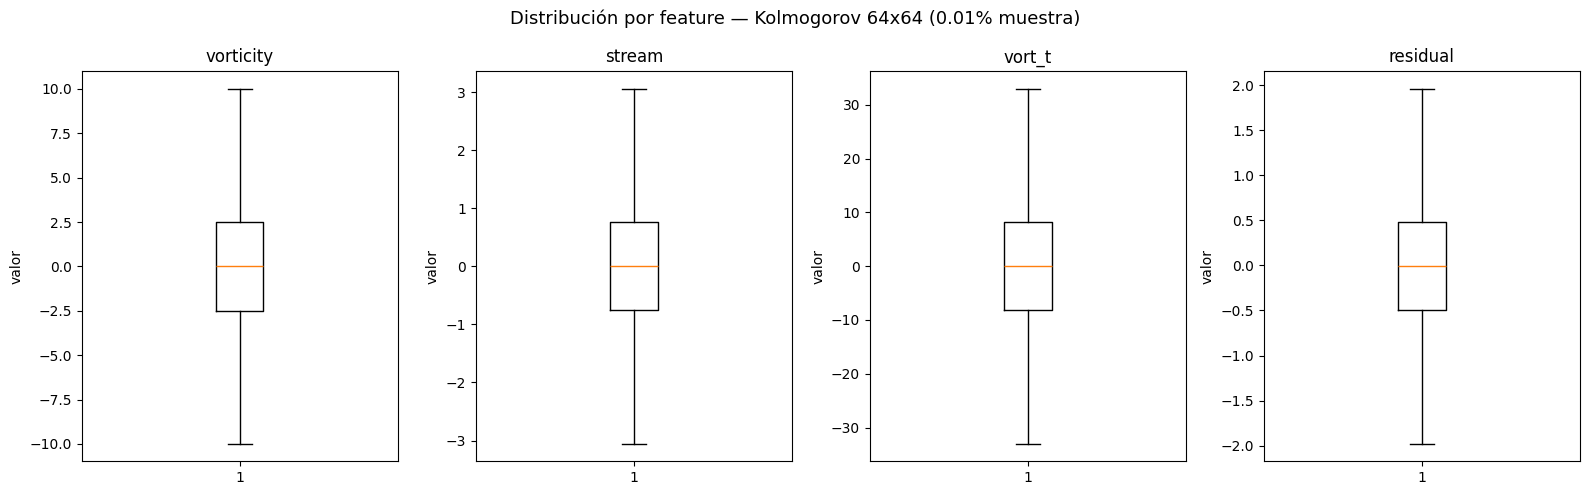

In [8]:
total = data['vorticity'].numel()
n_sample = int(total * 0.0001)
print(f'Usando {n_sample:,} elementos ({n_sample/total*100:.4f}% del total)')

keys = ['vorticity', 'stream', 'vort_t', 'residual']

torch.manual_seed(42)
samples = []
for k in keys:
    flat = data[k].flatten()
    idx = torch.randperm(len(flat))[:n_sample]
    samples.append(flat[idx].numpy())

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, (key, sample) in enumerate(zip(keys, samples)):
    axes[i].boxplot(sample, showfliers=False)
    axes[i].set_title(key)
    axes[i].set_ylabel('valor')

plt.suptitle('Distribución por feature — Kolmogorov 64x64 (0.01% muestra)', fontsize=13)
plt.tight_layout()
plt.show()

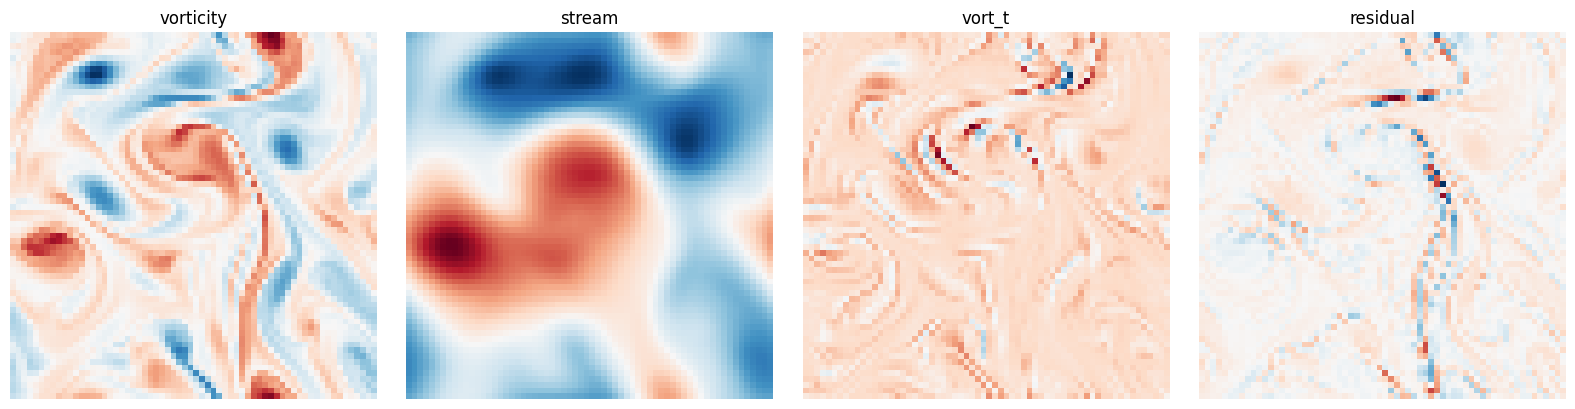

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
keys_to_plot = ['vorticity', 'stream', 'vort_t', 'residual']

for i, key in enumerate(keys_to_plot):
    val = data[key]
    frame = val[0, 0]
    axes[i].imshow(frame, cmap='RdBu_r')
    axes[i].set_title(key)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

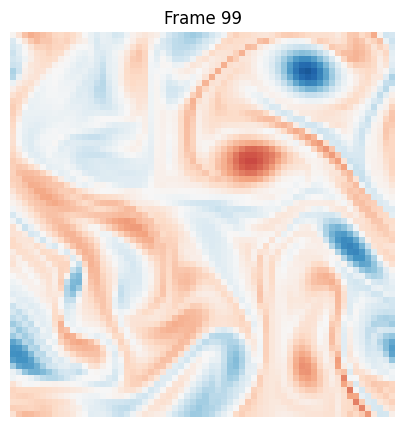

In [17]:
vort = data['vorticity'][0].numpy()

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(vort[0], cmap='RdBu_r', 
               vmin=vort.min(), vmax=vort.max())
ax.axis('off')
title = ax.set_title('Frame 0')

def update(t):
    im.set_data(vort[t])
    title.set_text(f'Frame {t}')
    return [im, title]

ani = animation.FuncAnimation(
    fig, update, frames=100, interval=50, blit=True
)

ani.save('vorticity_animation.gif', writer='pillow', fps=20)
plt.show()

#### __McWilliams2d_fp32_64x64_N1152_Re1000_T100.pt__

The principal characteristic of the McWilliams flow is that the turbulence is generated from a random initial vorticity field without any external forcing. The system evolves freely under the Navier–Stokes dynamics, so the resulting structures emerge purely from nonlinear interactions in the flow.

The initial vorticity field is typically constructed as a random superposition of Fourier modes concentrated around a characteristic wavenumber:

$$
\omega(x,y,0) = \sum_{k_1,k_2} A_{k_1,k_2}\,\sin(k_1 x + k_2 y + \phi_{k_1,k_2})
$$

where $A_{k_1,k_2}$ are amplitudes (often chosen to localize energy near a target wavenumber) and $\phi_{k_1,k_2}$ are random phases.

This initialization produces many small vortical structures that subsequently interact, merge, and reorganize, leading to the formation of larger coherent vortices typical of two–dimensional decaying turbulence.


In [3]:
path = '/media/joseluis/HDD/Proyecto CFD/datasets/scaomath_NS/McWilliams2d_fp32_64x64_N1152_Re1000_T100.pt'
data = torch.load(path, map_location='cpu', weights_only=False)

In [4]:
print(type(data))
print(data.keys())

<class 'collections.defaultdict'>
dict_keys(['vorticity', 'stream', 'vort_t', 'residual', 'random_states'])


In [5]:
for key in data.keys():
    val = data[key]
    print("Feature: ",key)
    print("Type of value in it: ",val.dtype)
    print("------------------------------------|")

Feature:  vorticity
Type of value in it:  torch.float32
------------------------------------|
Feature:  stream
Type of value in it:  torch.float32
------------------------------------|
Feature:  vort_t
Type of value in it:  torch.float32
------------------------------------|
Feature:  residual
Type of value in it:  torch.float32
------------------------------------|
Feature:  random_states
Type of value in it:  torch.int32
------------------------------------|


In [6]:
print(data['vorticity'].shape)

torch.Size([1152, 100, 64, 64])


Usando 47,185 elementos (0.0100% del total)


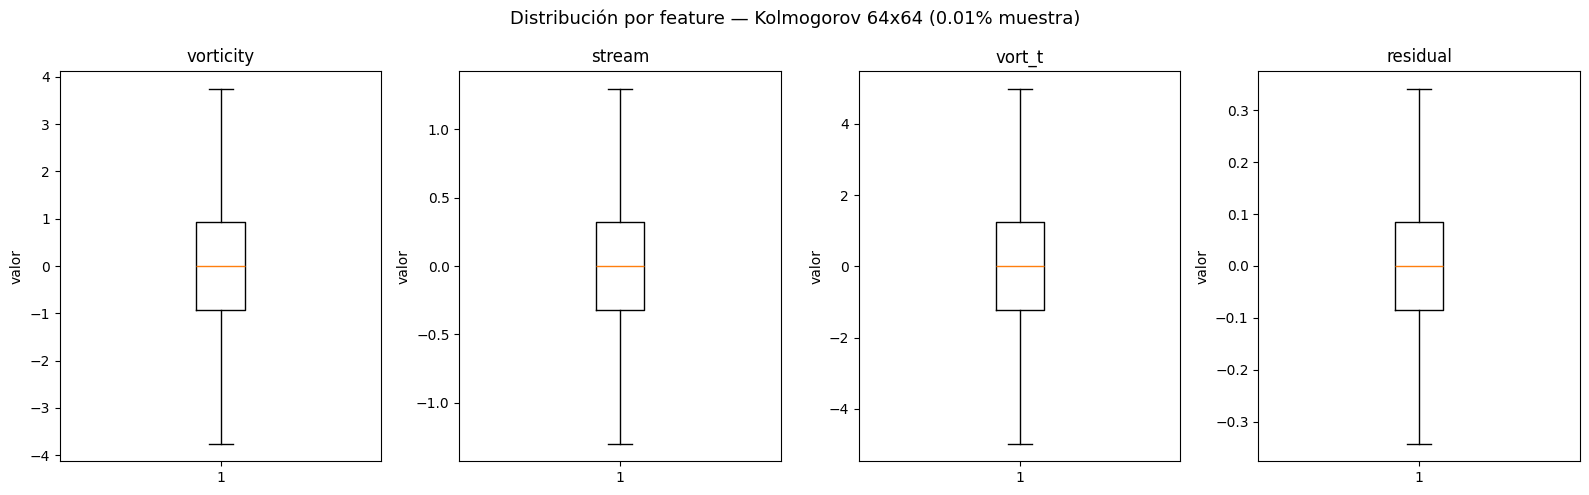

In [9]:
total = data['vorticity'].numel()
n_sample = int(total * 0.0001)
print(f'Usando {n_sample:,} elementos ({n_sample/total*100:.4f}% del total)')

keys = ['vorticity', 'stream', 'vort_t', 'residual']

torch.manual_seed(42)
samples = []
for k in keys:
    flat = data[k].flatten()
    idx = torch.randperm(len(flat))[:n_sample]
    samples.append(flat[idx].numpy())

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, (key, sample) in enumerate(zip(keys, samples)):
    axes[i].boxplot(sample, showfliers=False)
    axes[i].set_title(key)
    axes[i].set_ylabel('valor')

plt.suptitle('Distribución por feature — McWilliams 64x64 (0.01% muestra)', fontsize=13)
plt.tight_layout()
plt.show()

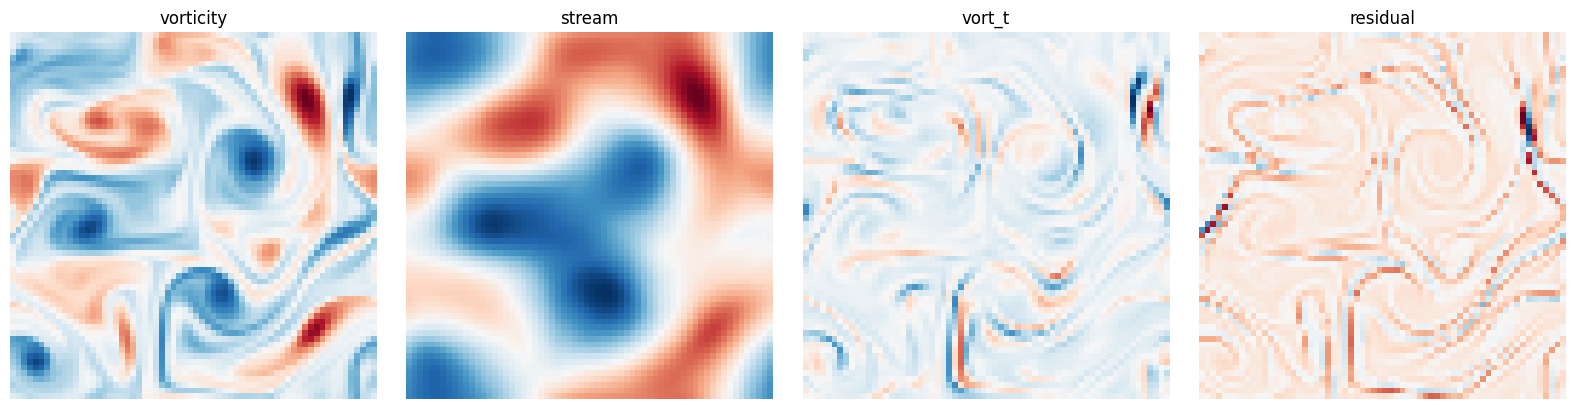

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
keys_to_plot = ['vorticity', 'stream', 'vort_t', 'residual']

for i, key in enumerate(keys_to_plot):
    val = data[key]
    frame = val[0, 0]
    axes[i].imshow(frame, cmap='RdBu_r')
    axes[i].set_title(key)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

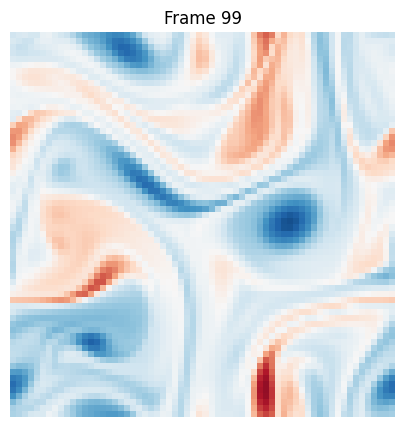

In [8]:
vort = data['vorticity'][0].numpy()

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(vort[0], cmap='RdBu_r', 
               vmin=vort.min(), vmax=vort.max())
ax.axis('off')
title = ax.set_title('Frame 0')

def update(t):
    im.set_data(vort[t])
    title.set_text(f'Frame {t}')
    return [im, title]

ani = animation.FuncAnimation(
    fig, update, frames=100, interval=50, blit=True
)

ani.save('vorticity_animation.gif', writer='pillow', fps=20)
plt.show()

#### __fnodata_extra_64x64_N1280_v1e-3_T50_steps100_alpha2.5_tau7.pt__

The fnodata flow is a two-dimensional Navier–Stokes system with stochastic forcing.  
The turbulence is sustained by an external random body force $f$ 
drawn from a Gaussian Random Field (GRF) with parameters $\alpha = 2.5$ and $\tau = 7$:

$$
\frac{\partial \omega}{\partial t} + \mathbf{u} \cdot \nabla \omega
= \nu \nabla^2 \omega + f,
\qquad
f \sim \text{GRF}(\alpha = 2.5,\ \tau = 7)
$$

where $\nu = 10^{-3}$ is the kinematic viscosity. The forcing injects energy 
continuously into the system at characteristic scales determined by $\tau$, 
while $\alpha$ controls the spatial smoothness of the forcing field.

This setup was introduced by Li et al. (2021) as a benchmark for neural operators 
and produces statistically stationary turbulence where energy input from forcing 
balances viscous dissipation.

In [2]:
path = '/media/joseluis/HDD/Proyecto CFD/datasets/scaomath_NS/fnodata_extra_64x64_N1280_v1e-3_T50_steps100_alpha2.5_tau7.pt'
data = torch.load(path, map_location='cpu', weights_only=False)

In [3]:
print(type(data))
print(data.keys())

<class 'collections.defaultdict'>
dict_keys(['vorticity', 'vorticity_t', 'stream', 'residual', 't_steps', 'random_states'])


In [4]:
for key in data.keys():
    val = data[key]
    print("Feature: ",key)
    print("Type of value in it: ",val.dtype)
    print("------------------------------------|")

Feature:  vorticity
Type of value in it:  torch.float32
------------------------------------|
Feature:  vorticity_t
Type of value in it:  torch.float32
------------------------------------|
Feature:  stream
Type of value in it:  torch.float32
------------------------------------|
Feature:  residual
Type of value in it:  torch.float32
------------------------------------|
Feature:  t_steps
Type of value in it:  torch.float32
------------------------------------|
Feature:  random_states
Type of value in it:  torch.int32
------------------------------------|


In [5]:
print(data['vorticity'].shape)

torch.Size([1280, 100, 64, 64])


There was a changue between var_names of definitions and an extra feature:

* vorticity_t: Equivalent to vort_t in the Kolmogorov 
  and McWilliams datasets.

* t_steps: Physical time coordinate of each frame, ranging from t=0.2 to t=20.0 
  with a fixed time step Δt=0.2. It defines the temporal axis of the simulation, 
  where each of the 100 frames corresponds to an elapsed physical time unit. 
  For a subsequence of 24 frames, this covers 4.8 physical time units of evolution.

Usando 52,428 elementos (0.0100% del total)


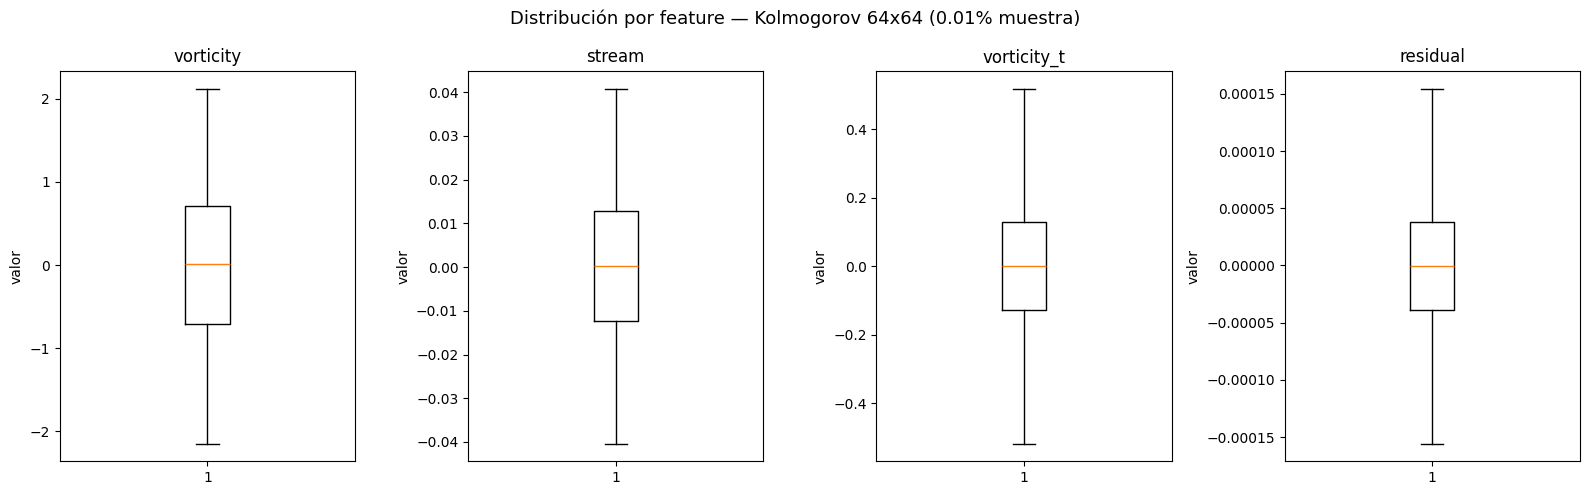

In [6]:
total = data['vorticity'].numel()
n_sample = int(total * 0.0001)
print(f'Usando {n_sample:,} elementos ({n_sample/total*100:.4f}% del total)')

keys = ['vorticity', 'stream', 'vorticity_t', 'residual']

torch.manual_seed(42)
samples = []
for k in keys:
    flat = data[k].flatten()
    idx = torch.randperm(len(flat))[:n_sample]
    samples.append(flat[idx].numpy())

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, (key, sample) in enumerate(zip(keys, samples)):
    axes[i].boxplot(sample, showfliers=False)
    axes[i].set_title(key)
    axes[i].set_ylabel('valor')

plt.suptitle('Distribución por feature — FNO 64x64 (0.01% muestra)', fontsize=13)
plt.tight_layout()
plt.show()

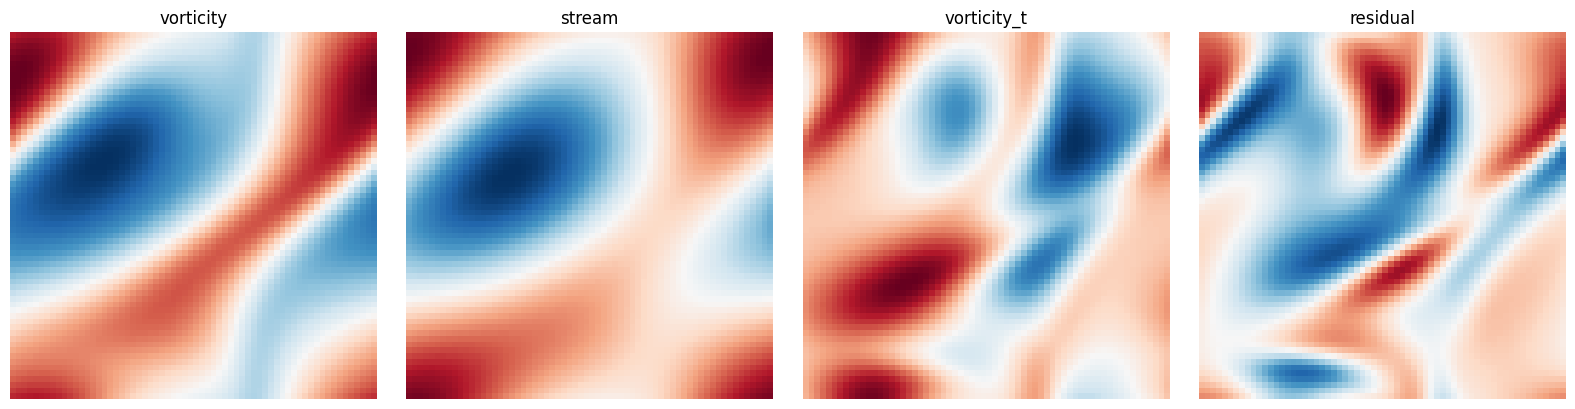

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
keys_to_plot = ['vorticity', 'stream', 'vorticity_t', 'residual']

for i, key in enumerate(keys_to_plot):
    val = data[key]
    frame = val[0, 0]
    axes[i].imshow(frame, cmap='RdBu_r')
    axes[i].set_title(key)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

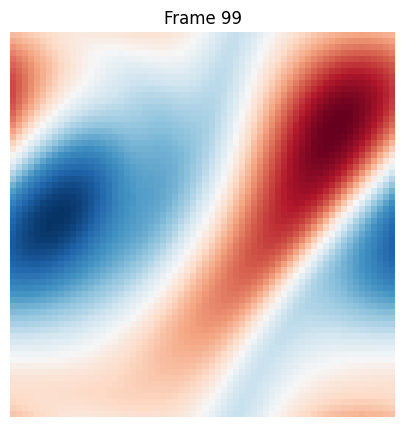

In [10]:
vort = data['vorticity'][0].numpy()

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(vort[0], cmap='RdBu_r', 
               vmin=vort.min(), vmax=vort.max())
ax.axis('off')
title = ax.set_title('Frame 0')

def update(t):
    im.set_data(vort[t])
    title.set_text(f'Frame {t}')
    return [im, title]

ani = animation.FuncAnimation(
    fig, update, frames=100, interval=50, blit=True
)

ani.save('vorticity_animation.gif', writer='pillow', fps=20)
plt.show()

### __The second dataset under analysis is KF256, a benchmark dataset designed for the study of turbulence and chaotic systems. It is primarily used to train deep learning models—such as Transformers—in fluid dynamics prediction. Published by Yi He on Zenodo in May 2025, this is a Kolmogorov vorticity dataset with a spatial resolution of 256x256 pixels. Because it is a Kolmogorov flow, it follows the standard dynamical equations for forced 2D turbulence.__

#### __Assigned Train Dir__

In [2]:
files = sorted(glob.glob('/media/joseluis/HDD/Proyecto CFD/datasets/KF256/v_vort_train/v_vort_train/*.npy'))
print(f'Total archivos: {len(files)}')
for f in files:
    print(f.split('/')[-1])

Total archivos: 6
v_vort_100_159.npy
v_vort_160_219.npy
v_vort_220_269.npy
v_vort_270_299.npy
v_vort_300_349.npy
v_vort_350_399.npy


In [3]:
for f in files:
    d = np.load(f, mmap_mode='r')
    print(f'{f.split("/")[-1]}: {d.shape}')

v_vort_100_159.npy: (50, 500, 256, 256)
v_vort_160_219.npy: (60, 500, 256, 256)
v_vort_220_269.npy: (50, 500, 256, 256)
v_vort_270_299.npy: (30, 500, 256, 256)
v_vort_300_349.npy: (50, 500, 256, 256)
v_vort_350_399.npy: (50, 500, 256, 256)


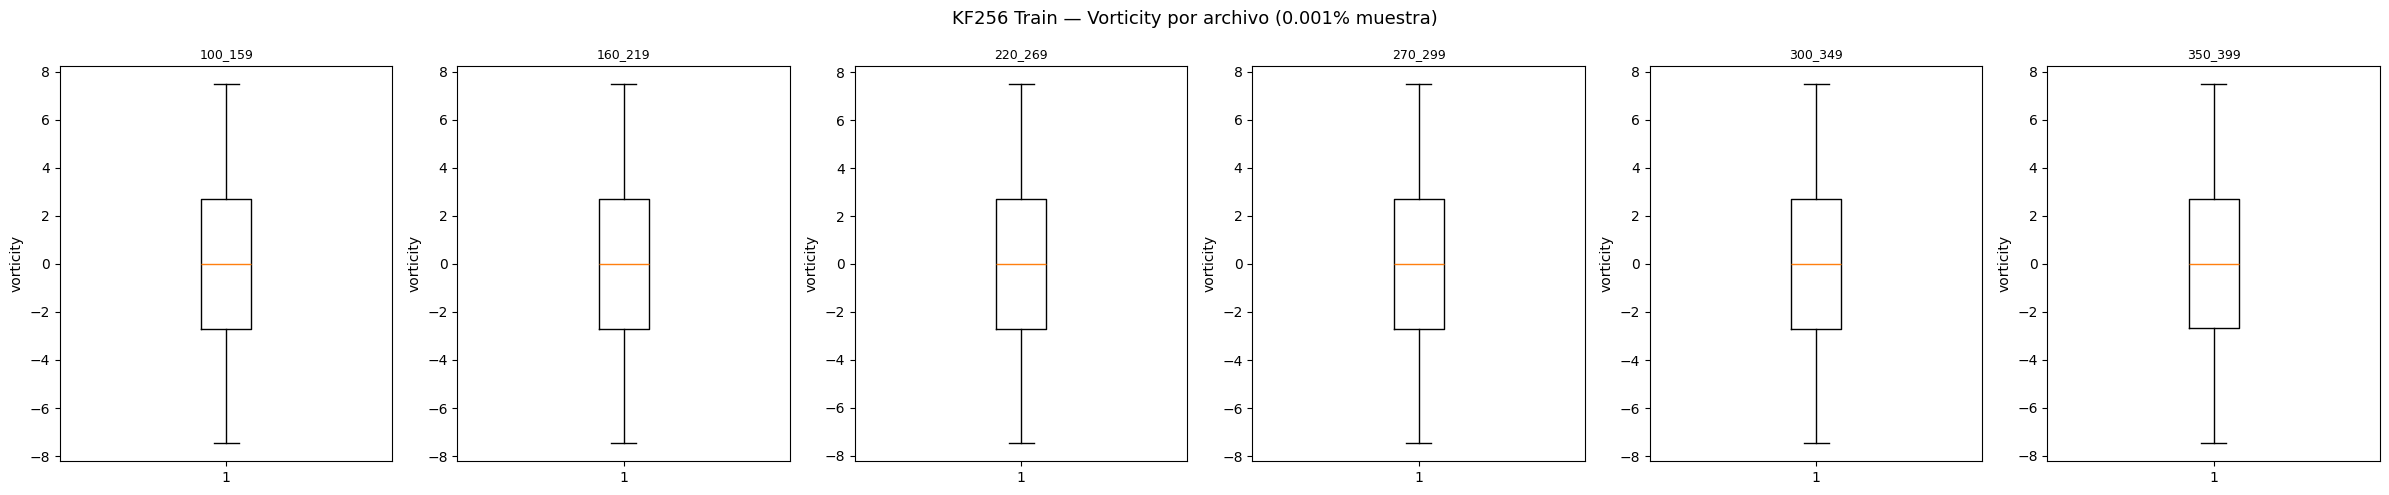

In [4]:
stats = []
labels = []

for f in files:
    d = np.load(f, mmap_mode='r')
    stats.append({
        'med':    float(np.median(d)),
        'q1':     float(np.percentile(d, 25)),
        'q3':     float(np.percentile(d, 75)),
        'whislo': float(np.percentile(d, 5)),
        'whishi': float(np.percentile(d, 95)),
        'fliers': []
    })
    labels.append(f.split('/')[-1].replace('v_vort_','').replace('.npy',''))
    del d

fig, axes = plt.subplots(1, 6, figsize=(24, 5))
for i, (stat, label) in enumerate(zip(stats, labels)):
    axes[i].bxp([stat], showfliers=False)
    axes[i].set_title(label, fontsize=9)
    axes[i].set_ylabel('vorticity')

plt.suptitle('KF256 Train — Vorticity por archivo (0.001% muestra)', fontsize=13)
plt.tight_layout()
plt.show()

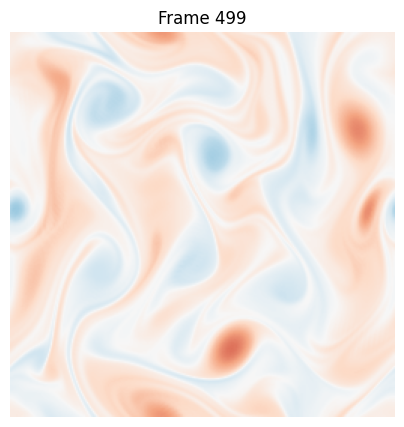

In [7]:
data_kf = np.load(
    '/media/joseluis/HDD/Proyecto CFD/datasets/KF256/v_vort_train/v_vort_train/v_vort_100_159.npy',
    mmap_mode='r'
)

traj = data_kf[0]

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(traj[0], cmap='RdBu_r', vmin=traj.min(), vmax=traj.max())
ax.axis('off')
title = ax.set_title('Frame 0')

def update(t):
    im.set_data(traj[t])
    title.set_text(f'Frame {t}')
    return [im, title]

ani = animation.FuncAnimation(fig, update, frames=500, interval=50, blit=True)
plt.show()

#### __Assigned Test File__

In [6]:
data_kf = np.load('/media/joseluis/HDD/Proyecto CFD/datasets/KF256/v_vort_test.npy', mmap_mode='r')
data_kf.shape

(30, 500, 256, 256)

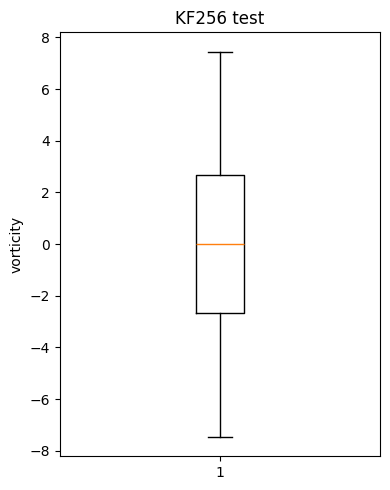

In [7]:
stat = {
    'med':    float(np.median(data_kf)),
    'q1':     float(np.percentile(data_kf, 25)),
    'q3':     float(np.percentile(data_kf, 75)),
    'whislo': float(np.percentile(data_kf, 5)),
    'whishi': float(np.percentile(data_kf, 95)),
    'fliers': []
}

fig, ax = plt.subplots(figsize=(4, 5))
ax.bxp([stat], showfliers=False)
ax.set_title('KF256 test')
ax.set_ylabel('vorticity')
plt.tight_layout()
plt.show()

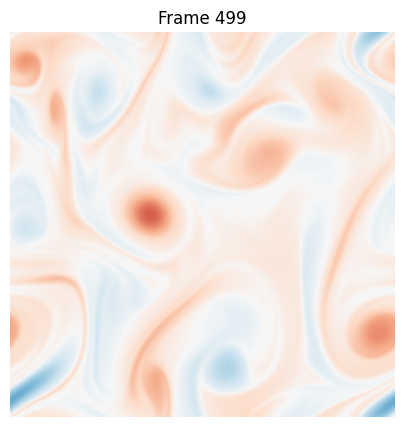

In [8]:
traj = data_kf[0]

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(traj[0], cmap='RdBu_r', vmin=traj.min(), vmax=traj.max())
ax.axis('off')
title = ax.set_title('Frame 0')

def update(t):
    im.set_data(traj[t])
    title.set_text(f'Frame {t}')
    return [im, title]

ani = animation.FuncAnimation(fig, update, frames=500, interval=50, blit=True)
ani.save('kf256_traj0.gif', writer='pillow', fps=20)
plt.show()

#### __Assigned Validation File__

In [11]:
data_kf = np.load('/media/joseluis/HDD/Proyecto CFD/datasets/KF256/v_vort_validate.npy', mmap_mode='r')
data_kf.shape

(40, 500, 256, 256)

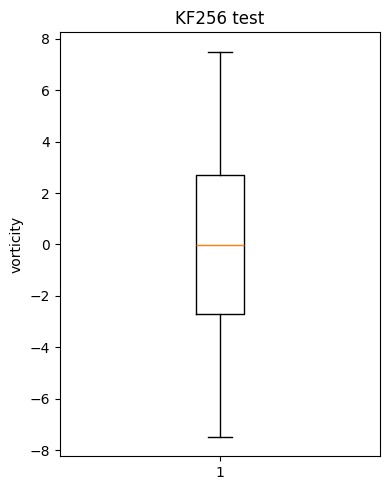

In [12]:
stat = {
    'med':    float(np.median(data_kf)),
    'q1':     float(np.percentile(data_kf, 25)),
    'q3':     float(np.percentile(data_kf, 75)),
    'whislo': float(np.percentile(data_kf, 5)),
    'whishi': float(np.percentile(data_kf, 95)),
    'fliers': []
}

fig, ax = plt.subplots(figsize=(4, 5))
ax.bxp([stat], showfliers=False)
ax.set_title('KF256 Val')
ax.set_ylabel('vorticity')
plt.tight_layout()
plt.show()

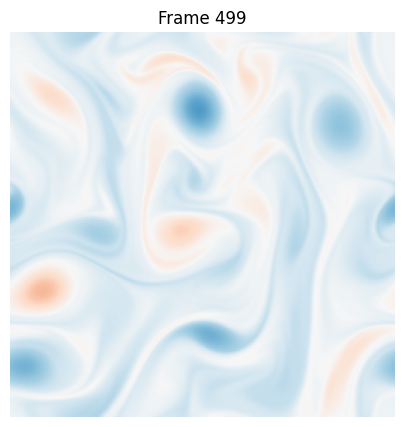

In [13]:
traj = data_kf[0]

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(traj[0], cmap='RdBu_r', vmin=traj.min(), vmax=traj.max())
ax.axis('off')
title = ax.set_title('Frame 0')

def update(t):
    im.set_data(traj[t])
    title.set_text(f'Frame {t}')
    return [im, title]

ani = animation.FuncAnimation(fig, update, frames=500, interval=50, blit=True)
ani.save('kf256_traj0.gif', writer='pillow', fps=20)
plt.show()

### __The third dataset we are analysing is NS2D (2D Navier-Stokes) dataset is a standard benchmark in computational fluid dynamics and machine learning for simulating incompressible, chaotic fluid motion. It represents a 2D turbulence, vortex dynamics problem, often solved using spectral methods to analyze the evolution of fluid vorticity over time. It also follow a kolmogorov vortex equation. In a 128x128 format.__

#### __Assigned Train File__

In [3]:
path = '/media/joseluis/HDD/Proyecto CFD/datasets/NS2D/nsforcing_train_128.pt'
data = torch.load(path, map_location='cpu', weights_only=False)

In [6]:
print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['x', 'y'])


In [7]:
for key in data.keys():
    val = data[key]
    print("Feature: ",key)
    print("Type of value in it: ",val.dtype)
    print("------------------------------------|")

Feature:  x
Type of value in it:  torch.float32
------------------------------------|
Feature:  y
Type of value in it:  torch.float32
------------------------------------|


In [9]:
print(data['x'].shape)
print(data['y'].shape)

torch.Size([10000, 128, 128])
torch.Size([10000, 128, 128])


In [29]:
print(f'Varianza:')
print(f'x range: [{data["x"].min():.4f}, {data["x"].max():.4f}] std={data["x"].std():.4f}')
print(f'y range: [{data["y"].min():.4f}, {data["y"].max():.4f}] std={data["y"].std():.4f}')

corr = torch.corrcoef(torch.stack([data['x'].flatten(), data['y'].flatten()]))[0,1]
print(f'\nCorrelación x-y: {corr:.4f}')

print(f'\nDiferencia entre feat. x & y:')
diff = data['y'][0] - data['x'][0]
print(f'Diferencia min: {diff.min():.4f}')
print(f'Diferencia max: {diff.max():.4f}')
print(f'Diferencia std: {diff.std():.4f}')

print(f'\nDiferencia entre muestra 0 y 1 para x:')
diff_traj = data['x'][1] - data['x'][0]
print(f'std: {diff_traj.std():.4f}')
print(f'Diferencia entre muestra 0 y 9999 para x:')
diff_far = data['x'][9999] - data['x'][0]
print(f'std: {diff_far.std():.4f}')

print(f'\nDiferencia entre muestra 0 y 1 para y:')
diff_traj = data['y'][1] - data['y'][0]
print(f'std: {diff_traj.std():.4f}')
print(f'Diferencia entre muestra 0 y 9999 para y:')
diff_far = data['y'][9999] - data['y'][0]
print(f'std: {diff_far.std():.4f}')

Varianza:
x range: [-0.7591, 0.8172] std=0.1539
y range: [-3.4890, 3.9279] std=0.7079

Correlación x-y: 0.8214

Diferencia entre feat. x & y:
Diferencia min: -1.1847
Diferencia max: 1.3928
Diferencia std: 0.5758

Diferencia entre muestra 0 y 1 para x:
std: 0.2114
Diferencia entre muestra 0 y 9999 para x:
std: 0.2608

Diferencia entre muestra 0 y 1 para y:
std: 1.0043
Diferencia entre muestra 0 y 9999 para y:
std: 1.1602


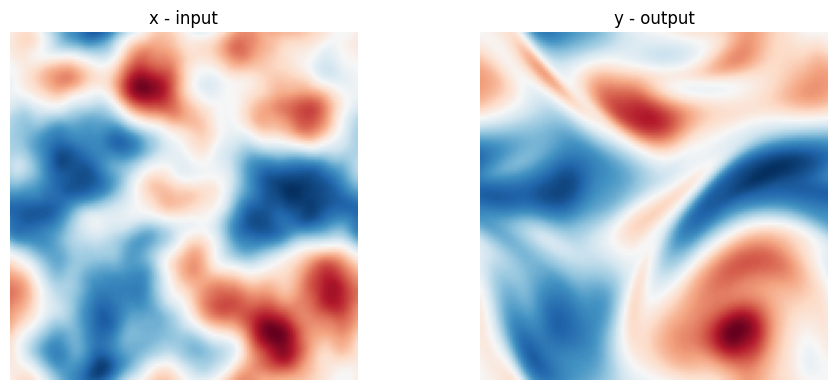

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(data['x'][0], cmap='RdBu_r')
axes[0].set_title('x - input')
axes[0].axis('off')

axes[1].imshow(data['y'][0], cmap='RdBu_r')
axes[1].set_title('y - output')
axes[1].axis('off')

plt.tight_layout()
plt.show()

#### __Assigned Test File__

In [32]:
path = '/media/joseluis/HDD/Proyecto CFD/datasets/NS2D/nsforcing_test_128.pt'
data = torch.load(path, map_location='cpu', weights_only=False)

In [33]:
print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['x', 'y'])


In [34]:
for key in data.keys():
    val = data[key]
    print("Feature: ",key)
    print("Type of value in it: ",val.dtype)
    print("------------------------------------|")

Feature:  x
Type of value in it:  torch.float32
------------------------------------|
Feature:  y
Type of value in it:  torch.float32
------------------------------------|


In [35]:
print(data['x'].shape)
print(data['y'].shape)

torch.Size([2000, 128, 128])
torch.Size([2000, 128, 128])


In [38]:
print(f'Varianza:')
print(f'x range: [{data["x"].min():.4f}, {data["x"].max():.4f}] std={data["x"].std():.4f}')
print(f'y range: [{data["y"].min():.4f}, {data["y"].max():.4f}] std={data["y"].std():.4f}')

corr = torch.corrcoef(torch.stack([data['x'].flatten(), data['y'].flatten()]))[0,1]
print(f'\nCorrelación x-y: {corr:.4f}')

print(f'\nDiferencia entre feat. x & y:')
diff = data['y'][0] - data['x'][0]
print(f'Diferencia min: {diff.min():.4f}')
print(f'Diferencia max: {diff.max():.4f}')
print(f'Diferencia std: {diff.std():.4f}')

print(f'\nDiferencia entre muestra 0 y 1 para x:')
diff_traj = data['x'][1] - data['x'][0]
print(f'std: {diff_traj.std():.4f}')
print(f'Diferencia entre muestra 0 y 9999 para x:')
diff_far = data['x'][1999] - data['x'][0]
print(f'std: {diff_far.std():.4f}')

print(f'\nDiferencia entre muestra 0 y 1 para y:')
diff_traj = data['y'][1] - data['y'][0]
print(f'std: {diff_traj.std():.4f}')
print(f'Diferencia entre muestra 0 y 9999 para y:')
diff_far = data['y'][1999] - data['y'][0]
print(f'std: {diff_far.std():.4f}')

Varianza:
x range: [-0.7624, 0.7503] std=0.1536
y range: [-3.6306, 3.6271] std=0.7062

Correlación x-y: 0.8028

Diferencia entre feat. x & y:
Diferencia min: -1.9037
Diferencia max: 1.7164
Diferencia std: 0.6156

Diferencia entre muestra 0 y 1 para x:
std: 0.1947
Diferencia entre muestra 0 y 9999 para x:
std: 0.2002

Diferencia entre muestra 0 y 1 para y:
std: 0.9472
Diferencia entre muestra 0 y 9999 para y:
std: 0.8896


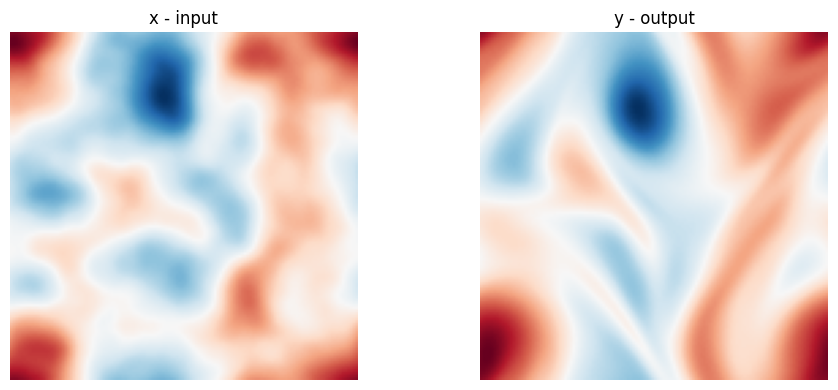

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(data['x'][0], cmap='RdBu_r')
axes[0].set_title('x - input')
axes[0].axis('off')

axes[1].imshow(data['y'][0], cmap='RdBu_r')
axes[1].set_title('y - output')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# __The election of the dataset for the project is kolmogorov 64x64 as it fits the purpose of the experiments. It also contains useful data as the stream field.__